In [397]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from sklearn.cluster import DBSCAN, HDBSCAN
from copy import copy
import sys

sys.path.append("../..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

import DriftCorrectionFunctions as DCF
drift_corrector = DCF.Drift_Correction_Functions()


H_F = HelperFunctions.Helper_Functions()

from src import FiducialDetection

FD = FiducialDetection.FiducialDetector()

from src import render
from src import postprocess as _postprocess
from src.LinkingFunctions import link_localisations

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

/tmp/ipykernel_3323602/2950206991.py:27: DeprecationWarning: PlottingFunctions.Plotter is deprecated and will be removed in a future version. Use PlottingBase.PublicationPlotter directly instead.
  plotter = PlottingFunctions.Plotter(dark_background=False)


In [2]:
data_folder = "../../Camera_Calibrations/Ximea_Camera"
gain_map = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset_map = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
read_noise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

pixel_QYs = np.vstack([B, G, R])
camera_parameters = {}
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]

In [3]:
data_folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/Data/Ximea/HeLaCellSTORM/20250523_HeLa_STORM/Cell4_HILO_190mW_638_ximea638_setting/Lp638_190_mw_40ms_exosure_HILO_1'

In [4]:
tif_files = H_F.file_search(data_folder, ".tif", "")
metadata_files = H_F.file_search(data_folder, "metadata", "")

In [5]:
localisation_files = H_F.file_search(data_folder, ".h5", "")

In [329]:
loc_data = pd.read_hdf(localisation_files[0])

In [330]:
x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])

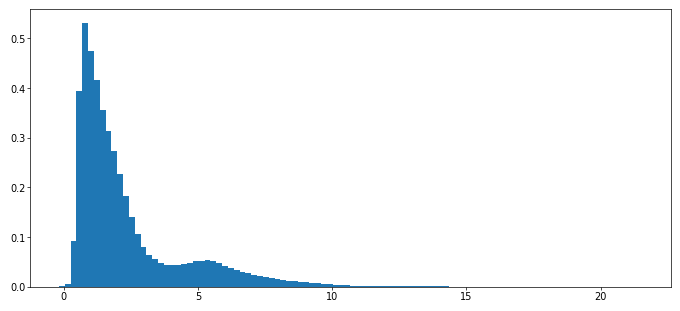

In [331]:
plt.hist(loc_data['spot_snr'], 100, density=True);
plt.show()

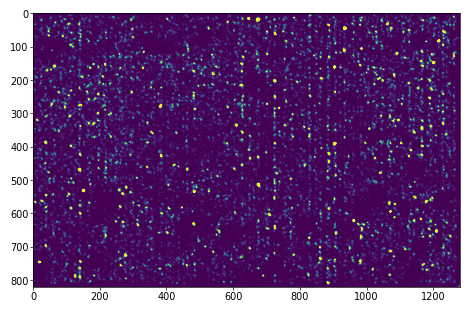

In [322]:
test = loc_data[(loc_data['spot_snr'] < 2) & (loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 100)]
#test2 = loc_data[(loc_data['spot_snr'] > 2) & (loc_data['photons'] > 1000) & (loc_data['spot_matched_filter_response'] > 100)]
#test2 = loc_data[loc_data['A_R'] < 0.8]
#test2 = loc_data[loc_data['A_G'] < 0.5]
#test = loc_data[loc_data['spot_snr'] < 2]

# s_x and s_y limits 100 and 175
# s_x_err and s_y_err < 30/69
# (loc_data['spot_snr'] > 2) & (loc_data['photons'] > 1000) & (loc_data['spot_matched_filter_response'] > 100)

image = render.render(
    locs=test.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

plt.imshow(image, vmax=np.percentile(image, 99))

In [183]:
np.min(image)

0.0

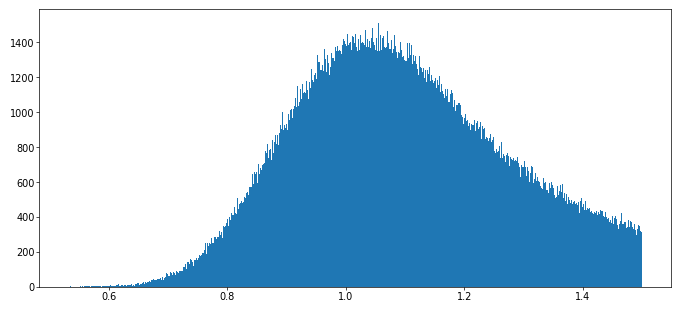

In [280]:
plt.hist(loc_data['chi_sqr'], 1000);
#plt.hist(test['spot_matched_filter_response'], 100);

plt.show()

In [332]:
loc_data = loc_data[loc_data["xc_err"] < 30/69]
loc_data = loc_data[loc_data["yc_err"] < 30/69]

loc_data = loc_data[loc_data["xc_err"] > 0]
loc_data = loc_data[loc_data["yc_err"] > 0]

loc_data = loc_data[loc_data["s_x_err"] < 30/69]
loc_data = loc_data[loc_data["s_y_err"] < 30/69]

loc_data = loc_data[(loc_data["s_x"] > 100/69) & (loc_data["s_x"] < 175/69)]
loc_data = loc_data[(loc_data["s_y"] > 100/69) & (loc_data["s_y"] < 175/69)]

loc_data = loc_data[loc_data["A_B_err"] < 0.01]
loc_data = loc_data[loc_data["A_G_err"] < 0.01]
loc_data = loc_data[loc_data["A_R_err"] < 0.01]

loc_data = loc_data[loc_data["A_B"] > 0.005]
loc_data = loc_data[loc_data["A_G"] > 0.05]
loc_data = loc_data[loc_data["A_R"] > 0.5]

loc_data = loc_data[loc_data["bg_B_err"] < 0.15]
loc_data = loc_data[loc_data["bg_G_err"] < 0.15]
loc_data = loc_data[loc_data["bg_R_err"] < 0.15]

loc_data = loc_data[~((loc_data['spot_snr'] < 2) & (loc_data['photons'] < 500) & (loc_data['spot_matched_filter_response'] < 100))]

loc_data = loc_data[loc_data["spot_background_std"] > 10]

#loc_data = loc_data[loc_data["photons"] < 100000]
#loc_data = loc_data[loc_data["photons"] > 100]


loc_data = loc_data[loc_data["chi_sqr"] < 1.5]

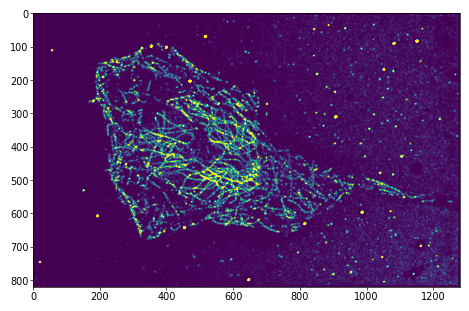

In [333]:
image = render.render(
    locs=loc_data.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

plt.imshow(image, vmax=np.percentile(image, 99))

In [334]:
drift_corrector = DCF.Drift_Correction_Functions()

info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(loc_data['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

corrected_locs, drift_result = drift_corrector.undrift(locs=loc_data.to_records(index=False),
                                          info=info,
                                          method="aim",
                                          segmentation=20,
                                            intersect_d=20/69,
                                          roi_r=60/69,
                                         )
corrected_locs = pd.DataFrame(corrected_locs)

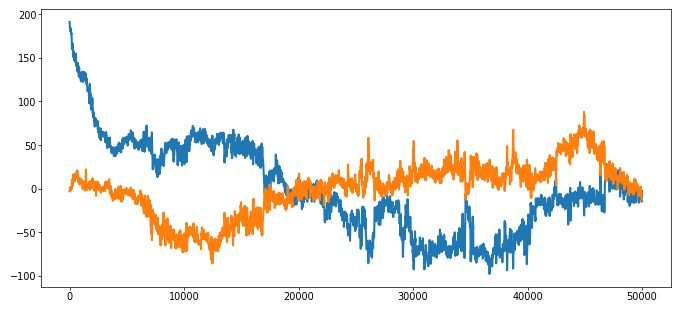

In [335]:
plt.plot(drift_result.drift_x*69)
plt.plot(drift_result.drift_y*69)

plt.show()

In [336]:
link_r = 0.5 * (np.median(corrected_locs['xc_err']) + np.median(corrected_locs['yc_err']))
linked = link_localisations(corrected_locs, n_frames=n_frames, r_max=link_r, max_dark_time=2)

In [337]:
image = render.render(
    locs=linked.to_records(index=False),
    oversampling=1,
    viewport=((0, 0), (height, width)),
    blur_method="smooth",
)[1]

/home/jsb92/Documents/pyBayerSMLM/src/DriftPlotting.py:1124: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


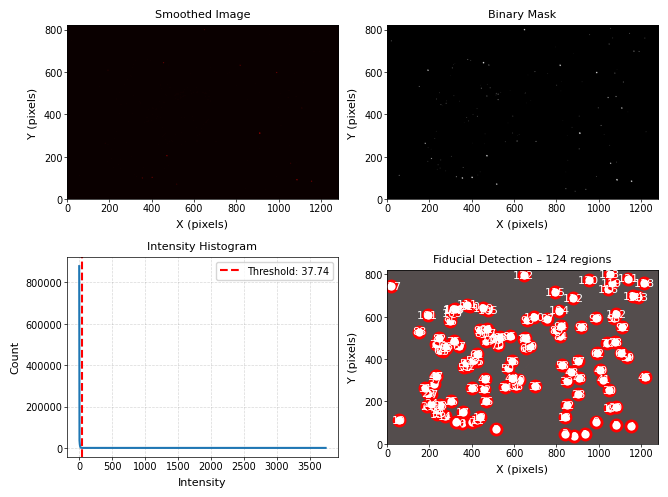

In [338]:
region_centers, binary_mask, threshold, metadata = drift_corrector.detect_high_density_regions_from_image(
      smoothed_image=image,
      histogram_bins=821,
      threshold_percentile=99.9,
      pixelsize=69.0,
      title="Fiducial Detection"
  )

Processed 101/124 regions (95 accepted, 6 rejected)                             1.06it/s]
Memory optimisation: Freed intermediate arrays after region processing


/home/jsb92/Documents/pyBayerSMLM/src/DriftPlotting.py:668: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


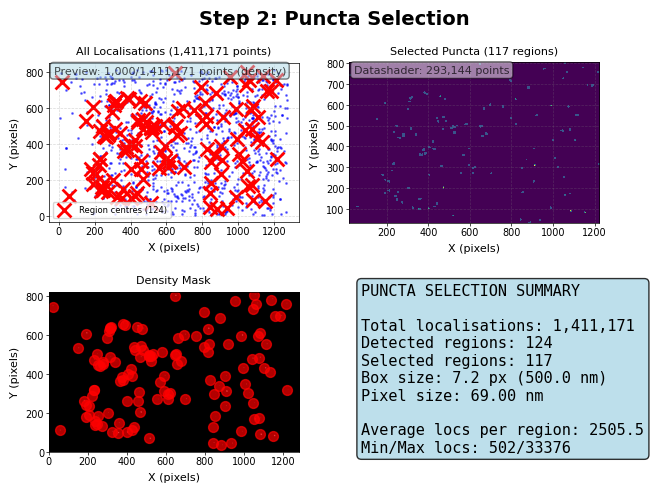

In [339]:
info = [{
    "Width": width,         # Image width in pixels
    "Height": height,        # Image height in pixels
    "Frames": np.max(linked['frame']),      # Total number of frames in the movie
    "Pixelsize": 69,        # pixel size always in nm
}]

selected_puncta, selection_metadata = drift_corrector.select_puncta_from_regions(
        locs=linked.to_records(index=False),                             # Your localization data
        region_centres=region_centers,         # Output from Step 1
        binary_mask=binary_mask,               # Output from Step 1
        pixelsize=info[0]['Pixelsize'],
        selection_box_size_nm=500.0,         # Box size around each region center (adjust as needed)
        min_localisations_per_region=int(0.01*info[0]['Frames']),      # Minimum locs for valid fiducial (adjust as needed)
        title="Step 2: Puncta Selection",
        create_plot=True
    )

In [340]:
linked_fremoved = FD.remove_puncta_locs(linked.to_records(index=False), selected_puncta)
linked_fremoved = pd.DataFrame(linked_fremoved)

remove_puncta_locs: removed 290,114 localisations (20.6% of 1,411,171 total)


In [454]:
oversampling=1
image_nofid = render.render(
    locs=corrected_locs.to_records(index=False),
    oversampling=oversampling,
    viewport=((0, 0), (height, width)),
    blur_method="gaussian",
)[1]

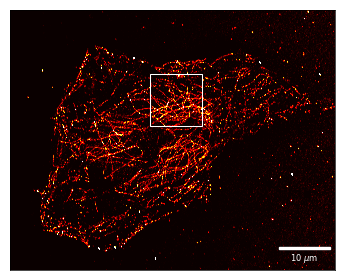

In [543]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=image_nofid[300:-300, 800:-2000],
    vmin=np.percentile(image_nofid, 1),
    vmax=np.percentile(image_nofid, 99.5),
    cbar="off",
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=10000,
    scalebarlabel=r"10 $\mu$m",
    cmap="hot",
)

import matplotlib.patches as patches

rect = patches.Rectangle(
    ((500 * oversampling) - 800, (450 * oversampling) - 300),
    150 * oversampling,
    150 * oversampling,
    linewidth=0.75,
    edgecolor="white",
    facecolor="none",
)

# Add the patch to the Axes
axs.add_patch(rect)

#[300:-300, 800:-2000]

plt.savefig("Exemplar_SuperRes_Box.svg", dpi=600, format="svg")
plt.show()

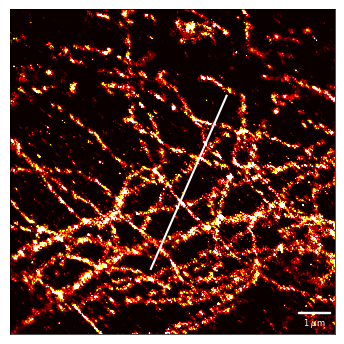

In [544]:
fig, axs = plotter.one_column_plot()

data = image_nofid[
        int(450 * oversampling) : int(450 * oversampling) + int(150 * oversampling),
        int(500) * oversampling : int(500) * oversampling + int(150 * oversampling),
    ]

axs = plotter.image_plot(
    axs=axs,
    data=data,
    vmin=np.percentile(image_nofid, 1),
    vmax=np.percentile(image_nofid, 99.5),
    cbar="off",
    cbarlabel="localisations",
    pixelsize=69 / oversampling,
    scalebarsize=1000,
    scalebarlabel=r"1 $\mu$m",
    cmap="hot",
)

# Coordinates of the line we'd like to sample along
line = [(65*oversampling, 30*oversampling), (100*oversampling, 110*oversampling)]

# Convert the line to pixel/index coordinates
x_world, y_world = np.array(list(zip(*line)))
col = x_world
row = y_world
axs.plot(x_world, y_world, color='white')

plt.savefig("Exemplar_SuperRes_Zoomin.svg", dpi=600, format="svg")
plt.show()

In [536]:
row

array([240, 880])

In [537]:
num = 1000
rowplot, colplot = [np.linspace(item[0], item[1], num) for item in [row, col]]

In [542]:
len(np.unique(colplot.astype(int)))

281

In [538]:
zi = data[rowplot.astype(int), colplot.astype(int)]

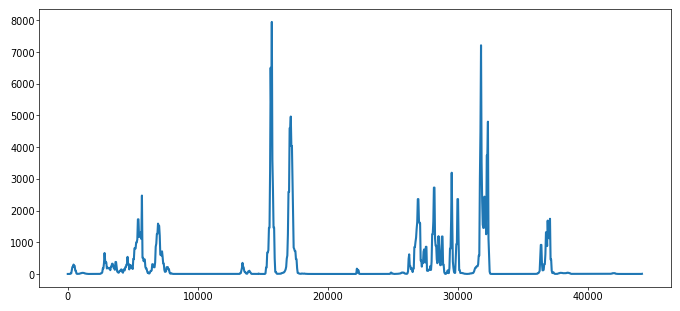

In [539]:
plt.plot(rowplot*69 - np.min(rowplot*69), zi)